In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_project_path
)

from flonacomldft.internal_coordinates import (
    Coordinates_mapping
)

from flonacomldft.utils.diagnostics import R_hat

In [3]:
methods = ['adaptive', 'mixture_model']

In [4]:
simulation_types = dict(zip( methods, [
                    ['ab-flowMC', 'ab-flowMC w.o. MLP'],
                    ['ab-flowMM', 'ab-flowMM w.o. MLP']
                ])
            )

In [5]:
simulation_types

{'adaptive': ['ab-flowMC', 'ab-flowMC w.o. MLP'],
 'mixture_model': ['ab-flowMM', 'ab-flowMM w.o. MLP']}

In [6]:
simulation_idxs = { methods[0]: { simulation_types[methods[0]][0]: {
                        0: 31959918,
                        1: 319599111
                        #0: 31959917,
                        #1: 319599110
                    },

                    simulation_types[methods[0]][1]: {
                        0: 31961552,
                        1: 31961553
                    }
                },

                methods[1]: { 
                    simulation_types[methods[1]][0]: 
                        32094541,
                    simulation_types[methods[1]][1]:
                        32094594
                        
                }
            }

In [7]:
simulation_idxs

{'adaptive': {'ab-flowMC': {0: 31959918, 1: 319599111},
  'ab-flowMC w.o. MLP': {0: 31961552, 1: 31961553}},
 'mixture_model': {'ab-flowMM': 32094541, 'ab-flowMM w.o. MLP': 32094594}}

In [8]:
simulations_folders = {
    
    methods[0]: {
    simulation_types[methods[0]][0]: get_project_path() + "/2-adaptive-mlp",
    simulation_types[methods[0]][1]: get_project_path() + "/1-adaptive"
    },

    methods[1]: {
    simulation_types[methods[1]][0]: get_project_path() + "/5-multimodal-mlp",
    simulation_types[methods[1]][1]: get_project_path() + "/4-multimodal"
    }
}

save_path = get_project_path() + "/figures/preprint_v2/data"

In [9]:
simulations_folders

{'adaptive': {'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
  'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'},
 'mixture_model': {'ab-flowMM': '/mnt/home/amolina/ceph/adaptive-flow-mc/5-multimodal-mlp',
  'ab-flowMM w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/4-multimodal'}}

In [10]:
get_simulation_filename_adaptive = lambda isomer_label, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
    isomer_label, idx, isomer_label, idx)
get_cvs_filename_adaptive = lambda isomer_label, idx: "results_adaptive_is{:d}_{:d}/cvs_is{:d}_{:d}.pkl".format(
    isomer_label, idx, isomer_label, idx)

In [11]:
get_simulation_filename_mm = lambda idx: "results_multimodal_sampling_mixture_{:d}/checkpoint_NA_3000.pkl".format(
    idx)
get_cvs_filename_mm = lambda idx: "cvs_temporal/cvs_slices_{:d}_3000.pkl".format(
    idx)

In [12]:
simulations_folders[methods[0]]

{'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
 'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'}

# 1. Ab-flowMC simulations

In [13]:
method = methods[0]

adaptives = {}
cvss = {}

print("Loading data...")
for simulation in simulation_types[method]:
    adaptives[simulation] = {}
    cvss[simulation] = {}
    for key, idx in simulation_idxs[method][simulation].items():
        adaptives[simulation][key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
        simulations_folders[method][simulation])
        cvss[simulation][key] = load_pickle_file(get_cvs_filename_adaptive(key, idx),
        simulations_folders[method][simulation])
        print("Loaded adaptive sampling {:s} and cvs for isomer {:d} and idx {:d}".format(
            simulation, key, idx))

Loading data...


Loaded adaptive sampling ab-flowMC and cvs for isomer 0 and idx 31959918
Loaded adaptive sampling ab-flowMC and cvs for isomer 1 and idx 319599111
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 0 and idx 31961552
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 1 and idx 31961553


In [14]:
adaptive = adaptives[simulation_types[method][0]][0]

## 1.a Acceptance rate

In [15]:
accs_df = []

for simulation in simulation_types[method]:
    
    for key, idx in simulation_idxs[method][simulation].items():

        df = pd.DataFrame(columns=['Method', 'Isomer', 'Step', 'Acceptance Rate'])
        accs = torch.cat(adaptives[simulation][key]['accs']).float().mean(dim=1).numpy()

        df['Acceptance Rate'] = accs
        df['Isomer'] = key
        df['Step'] = np.arange(0, len(accs))
        df['Method'] = simulation

        accs_df.append(df)

accs_df = pd.concat(accs_df)
accs_df.to_csv(save_path + "/acceptance_rates.csv", index=False)
print("Acceptance rates saved to {:s}".format(save_path + "/acceptance_rates.csv"))

Acceptance rates saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/acceptance_rates.csv


## 1.b Collective variables and potential energy

In [16]:
cvs_us_df = []

for simulation in simulation_types[method]:
    for isomer_label in [0, 1]:

        us = torch.cat(adaptives[simulation][isomer_label]['us']).reshape(1000, 50, 1)
        cvs = cvss[simulation][isomer_label]

        cvs_us = torch.cat([us, cvs], dim=2).numpy().reshape(50000, 3)

        df = pd.DataFrame(cvs_us, columns=['U', 'C', 'R'])
        df['Isomer'] = isomer_label
        df['Method'] = simulation

        cvs_us_df.append(df)

cvs_us_df = pd.concat(cvs_us_df)
cvs_us_df.to_csv(save_path + "/cvs_potential_energy.csv", index=False)
print("CVs and potential energy saved to {:s}".format(save_path + "/cvs_potential_energy.csv"))
cvs_us_df

CVs and potential energy saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/cvs_potential_energy.csv


,U,C,R,Isomer,Method
0,-6.710232,9.602885,2.474888,0,ab-flowMC
1,-6.729107,9.889919,2.459191,0,ab-flowMC
2,-6.699037,9.428088,2.465139,0,ab-flowMC
3,-6.715884,10.055170,2.446292,0,ab-flowMC
4,-6.771481,9.686485,2.485445,0,ab-flowMC
...,...,...,...,...,...
49995,-6.704685,10.828248,2.220704,1,ab-flowMC w.o. MLP
49996,-6.746437,10.425041,2.232781,1,ab-flowMC w.o. MLP
49997,-6.714196,11.065727,2.218863,1,ab-flowMC w.o. MLP
49998,-6.743561,11.145951,2.213711,1,ab-flowMC w.o. MLP


## 1.c Rhat

In [17]:
rhat_df = []

for simulation in simulation_types[method]:
    for isomer_label in [0, 1]:

        us = torch.cat(adaptives[simulation][isomer_label]['us']).reshape(1000, 50, 1)
        cvs = cvss[simulation][isomer_label]
        
        time_slices = adaptives[simulation][isomer_label]['time_mcmc']
        time_flatten = [t for time_slice in time_slices for t in time_slice]
        time_min = min(time_flatten)
        time_mcmc = np.array([t - time_min for t in time_flatten])/3600

        rhat_info = torch.cat((cvs, us), dim=2).detach().numpy()[500:].transpose(1, 0, 2)

        rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])

        df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
        df['Time (h)'] = time_mcmc[rhat[1]]
        df['MCMC step'] = rhat[1]
        df['Method'] = simulation
        df['Isomer'] = isomer_label

        rhat_df.append(df)

rhat_df = pd.concat(rhat_df)
rhat_df.to_csv(save_path + "/rhat.csv", index=False)        
rhat_df

,C,R,U,Time (h),MCMC step,Method,Isomer
0,1.275703,1.276311,1.235690,1.153013,40,ab-flowMC,0
1,1.181835,1.153089,1.131222,2.338277,80,ab-flowMC,0
2,1.101193,1.093196,1.087635,3.519732,120,ab-flowMC,0
3,1.077191,1.063065,1.066412,4.723922,160,ab-flowMC,0
4,1.055001,1.050816,1.049729,5.945965,200,ab-flowMC,0
5,1.044319,1.040300,1.043435,7.170012,240,ab-flowMC,0
6,1.042227,1.036513,1.029278,8.399153,280,ab-flowMC,0
7,1.036227,1.030463,1.025004,9.622912,320,ab-flowMC,0
8,1.027994,1.026882,1.019465,10.847459,360,ab-flowMC,0
9,1.023479,1.024966,1.016149,12.069186,400,ab-flowMC,0


## 1.d MLP datasets

In [18]:
mlp_datasets_df = []

simulation = simulation_types[method][0]

for isomer_label in [0, 1]:
    datasets = adaptives[simulation][isomer_label]['mlps_datasets']
    models = adaptives[simulation][isomer_label]['dict_mlps'][-1][0]['model']
    for key in ['train', 'test']:
        df = pd.DataFrame(columns=['Predictions', 'True values'])
    
        data = datasets[key][0].detach().numpy()
        predict = models(torch.tensor(data[:, :12]).float()).detach().numpy()

        df['True values'] = data[:, 12]
        df['Predictions'] = predict
        df['Isomer'] = isomer_label
        df['Dataset'] = key.capitalize()
        df['Method'] = simulation

        mlp_datasets_df.append(df)

mlp_datasets_df = pd.concat(mlp_datasets_df)
mlp_datasets_df.to_csv(save_path + "/mlp_datasets.csv", index=False)
print("MLP datasets saved to {:s}".format(save_path + "/mlp_datasets.csv"))


MLP datasets saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/mlp_datasets.csv


## 1.d Optical spectrum

# 2. Ab-flowMM

In [19]:
method, simulation_idxs[method].items()

('adaptive',
 dict_items([('ab-flowMC', {0: 31959918, 1: 319599111}), ('ab-flowMC w.o. MLP', {0: 31961552, 1: 31961553})]))

In [20]:
method = methods[1]

mixture_models = {}
cvs_mixture_models = {}

print("Loading data...")
for key, idx in simulation_idxs[method].items():
    print(key, idx)
    mixture_models[key] = load_pickle_file(get_simulation_filename_mm(idx), 
    simulations_folders[method][key])
    cvs_mixture_models[key] = load_pickle_file(get_cvs_filename_mm(idx),
    get_project_path())
    print("Loaded mixture model sampling {:s} and cvs and idx {:d}".format(
        key, idx))

Loading data...
ab-flowMM 32094541
Loaded mixture model sampling ab-flowMM and cvs and idx 32094541
ab-flowMM w.o. MLP 32094594
Loaded mixture model sampling ab-flowMM w.o. MLP and cvs and idx 32094594


## 2a. Acceptace rate

In [23]:
mixture_models.keys()

dict_keys(['ab-flowMM', 'ab-flowMM w.o. MLP'])

In [24]:
accs_df_mm = []

    
for key in mixture_models.keys():

    df = pd.DataFrame(columns=['Method', 'Isomer', 'Step', 'Acceptance Rate'])
    accs = mixture_models[key]['accs'].float().mean(dim=1).numpy()

    df['Acceptance Rate'] = accs
    df['Isomer'] = key
    df['Step'] = np.arange(0, len(accs))
    df['Method'] = key

    accs_df_mm.append(df)

accs_df_mm = pd.concat(accs_df_mm)
accs_df_mm.to_csv(save_path + "/acceptance_rates_mm.csv", index=False)
print("Acceptance rates saved to {:s}".format(save_path + "/acceptance_rates_mm.csv"))

Acceptance rates saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/acceptance_rates_mm.csv


In [25]:
accs_df_mm

,Method,Isomer,Step,Acceptance Rate
0,ab-flowMM,ab-flowMM,0,0.45
1,ab-flowMM,ab-flowMM,1,0.25
2,ab-flowMM,ab-flowMM,2,0.30
3,ab-flowMM,ab-flowMM,3,0.40
4,ab-flowMM,ab-flowMM,4,0.30
...,...,...,...,...
2996,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2996,0.25
2997,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2997,0.30
2998,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2998,0.50
2999,ab-flowMM w.o. MLP,ab-flowMM w.o. MLP,2999,0.45


## 2.b Collective variables and potential energy

In [26]:
cvs_us_df_mm = []

for key in mixture_models.keys():

    us = mixture_models[key]['us'].reshape(3001, 20, 1)
    isomers = mixture_models[key]['isomers'].reshape(3001, 20, 1)
    cvs = cvs_mixture_models[key]
    cvs_us = torch.cat([us, cvs, isomers], dim=2).numpy().reshape(60020, 4)
    df = pd.DataFrame(cvs_us, columns=['U', 'C', 'R', 'Isomer'])
    df['Method'] = key
    cvs_us_df_mm.append(df)

cvs_us_df_mm = pd.concat(cvs_us_df_mm)
cvs_us_df_mm.to_csv(save_path + "/cvs_potential_energy_mm.csv", index=False)
print("CVs and potential energy saved to {:s}".format(save_path + "/cvs_potential_energy.csv"))
cvs_us_df

CVs and potential energy saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/cvs_potential_energy.csv


,U,C,R,Isomer,Method
0,-6.773585,10.105214,2.457276,0,ab-flowMC
1,-6.750111,10.205934,2.442652,0,ab-flowMC
2,-6.764058,9.652035,2.473082,0,ab-flowMC
3,-6.732985,10.172332,2.427748,0,ab-flowMC
4,-6.748763,9.293897,2.517407,0,ab-flowMC
...,...,...,...,...,...
49995,-6.704685,10.828248,2.220704,1,ab-flowMC w.o. MLP
49996,-6.746437,10.425041,2.232781,1,ab-flowMC w.o. MLP
49997,-6.714196,11.065727,2.218863,1,ab-flowMC w.o. MLP
49998,-6.743561,11.145951,2.213711,1,ab-flowMC w.o. MLP


## 2.c Density samples

In [27]:
simulation_types['adaptive']

['ab-flowMC', 'ab-flowMC w.o. MLP']

In [29]:
#models = {}
#
#for simulation in simulation_types.keys():
#    for key in mixture_models.keys():
#        models[simulation] = mixture_models[key]['models']

## 2.d Rhat

In [30]:
mixture_models['ab-flowMM']['time_mcmc']

[1708189151.0943224,
 1708189174.2343788,
 1708189195.588432,
 1708189214.7881203,
 1708189234.200983,
 1708189258.52606,
 1708189281.175341,
 1708189303.967947,
 1708189327.502511,
 1708189349.9778516,
 1708189368.9729922,
 1708189390.6472232,
 1708189412.9873347,
 1708189436.6245706,
 1708189462.4731402,
 1708189485.3448074,
 1708189508.380226,
 1708189532.071178,
 1708189553.3794088,
 1708189576.5040863,
 1708189594.4745004,
 1708189619.405209,
 1708189640.1275144,
 1708189661.7312138,
 1708189689.228767,
 1708189709.1145444,
 1708189734.914357,
 1708189753.793246,
 1708189774.7511375,
 1708189801.594333,
 1708189819.8925445,
 1708189841.774198,
 1708189864.8293457,
 1708189883.103205,
 1708189906.264728,
 1708189930.2061539,
 1708189948.5213995,
 1708189967.9747782,
 1708189992.6623697,
 1708190010.445664,
 1708190034.2037446,
 1708190055.3663304,
 1708190076.0757465,
 1708190093.7077901,
 1708190113.6783462,
 1708190138.511592,
 1708190157.0238364,
 1708190185.494059,
 1708190204.

In [31]:
rhat_df_mm = []

for key in mixture_models.keys():

    us = mixture_models[key]['us'].reshape(3001, 20, 1)
    cvs = cvs_mixture_models[key]
    
    time_mm = mixture_models[key]['time_mcmc']
    time_min = min(time_mm)
    time_mcmc = np.array([t - time_min for t in time_mm])/3600

    rhat_info = torch.cat((cvs, us), dim=2).detach().numpy().transpose(1, 0, 2)

    rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])

    df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
    df['Time (h)'] = time_mcmc[rhat[1]]
    df['MCMC step'] = rhat[1]
    df['Method'] = key

    rhat_df_mm.append(df)

rhat_df_mm = pd.concat(rhat_df_mm)
rhat_df_mm.to_csv(save_path + "/rhat_mm.csv", index=False)        
rhat_df_mm

,C,R,U,Time (h),MCMC step,Method
0,1.244847,1.203371,1.201282,1.728772,290,ab-flowMM
1,1.221467,1.188414,1.174443,3.484163,580,ab-flowMM
2,1.130501,1.171119,1.089868,5.252929,870,ab-flowMM
3,1.101117,1.171875,1.096969,7.032640,1160,ab-flowMM
4,1.085846,1.177203,1.099640,8.837655,1450,ab-flowMM
5,1.085960,1.175499,1.074861,10.671688,1740,ab-flowMM
6,1.080660,1.156738,1.070799,12.524613,2030,ab-flowMM
7,1.081210,1.160547,1.075155,14.406494,2320,ab-flowMM
8,1.079550,1.164322,1.074507,16.304235,2610,ab-flowMM
9,1.078325,1.156593,1.064598,18.301156,2901,ab-flowMM


## 2.e Isomers

In [32]:
isomers_jumps = []

for key in mixture_models.keys():
    
    isomers = mixture_models[key]['isomers'].int()#.reshape(3001, 20, 1)

    df = pd.DataFrame(isomers, columns=['chain {:d}'.format(i) for i in np.arange(20)])
    df['Step'] = np.arange(0, 3001)
    df['Method'] = key
    
    isomers_jumps.append(df)

isomers_jumps = pd.concat(isomers_jumps)
isomers_jumps.to_csv(save_path + "/isomers_jumps_mm.csv", index=False)
print("Isomers jumps saved to {:s}".format(save_path + "/isomers_jumps_mm.csv"))

Isomers jumps saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/isomers_jumps_mm.csv


## 2.f Populations

In [33]:
mm_idx = {'ab-flowMM': {5: 32094540,
            15: 32094541,
            30: 32094542 
            },
        
        'ab-flowMM w.o. MLP': {5: 32094593,
            15: 32094594,
            30: 32094595    
            }
        }

In [34]:
mixture_models_populations = {}

for method in mm_idx.keys():
    
    mixture_models_populations[method] = {}

    for key, idx in mm_idx[method].items():
        mixture_models_populations[method][key] = load_pickle_file(get_simulation_filename_mm(idx), 
        simulations_folders['mixture_model'][method])['isomers']

In [35]:
isomers = mixture_models_populations['ab-flowMM'][5][250:].detach().numpy()
means = isomers.T.reshape(10, isomers.shape[0]*2).mean(axis=1)
stds = isomers.T.reshape(10, isomers.shape[0]*2).std(axis=1)

In [36]:
populations_mm_df = []

for key in mixture_models_populations.keys():

    for i in mixture_models_populations[key].keys():
        
        populations_mm = pd.DataFrame()

        isomers_selection = mixture_models_populations[key][i][250:].detach().numpy()
        means = isomers_selection.T.reshape(10, isomers_selection.shape[0]*2).mean(axis=1)
        stds = isomers_selection.T.reshape(10, isomers_selection.shape[0]*2).std(axis=1)
        
        populations_mm['means'] = means
        populations_mm['stds'] = stds
        populations_mm['slice'] = i
        populations_mm['Method'] = key

        populations_mm_df.append(populations_mm)

populations_mm_df = pd.concat(populations_mm_df)
populations_mm_df.to_csv(save_path + "/populations_mm.csv", index=False)
print("Populations saved to {:s}".format(save_path + "/populations_mm.csv"))

Populations saved to /mnt/home/amolina/ceph/adaptive-flow-mc/figures/preprint_v2/data/populations_mm.csv


# Losses MLP

In [21]:
idxs_old_new = {'old': {0: 30019620,
                        1: 30019624},
                'new': {0: 31959918,
                        1: 319599111}
                }

In [22]:
adaptives_old_new = {}

for sim in idxs_old_new.keys():
    adaptives_old_new[sim] = {}
    for key, idx in idxs_old_new[sim].items():
        adaptives_old_new[sim][key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
        simulations_folders['adaptive']['ab-flowMC'])
        print("Loaded adaptive sampling {:s} for isomer {:d} and idx {:d}".format(
            sim, key, idx))

Loaded adaptive sampling old for isomer 0 and idx 30019620
Loaded adaptive sampling old for isomer 1 and idx 30019624
Loaded adaptive sampling new for isomer 0 and idx 31959918
Loaded adaptive sampling new for isomer 1 and idx 319599111


Text(0.5, 0.98, 'Train and test losses Pretraining MLPs')

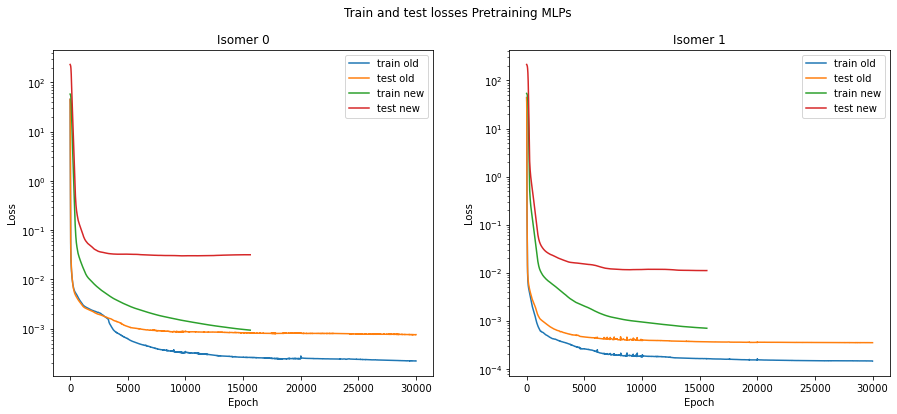

In [23]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

for sim in adaptives_old_new.keys():
    for key in adaptives_old_new[sim].keys():
        train_losses = []
        test_losses = []
        training = adaptives_old_new[sim][key]['dict_mlps'][0]
        if sim == 'old':
            train_losses.append(training[0]['train_losses'])
            test_losses.append(training[0]['test_losses'])
        if sim == 'new':
            train_losses.append(training[0]['avg_train_losses'])
            test_losses.append(training[0]['avg_test_losses'])
        train_losses_flat = [loss for sublist in train_losses for loss in sublist]
        test_losses_flat = [loss for sublist in test_losses for loss in sublist]
        
        axs[key].plot(train_losses_flat, label='train {:s}'.format(sim))
        axs[key].plot(test_losses_flat, label='test {:s}'.format(sim))

        axs[key].set_title('Isomer {:d}'.format(key))
        axs[key].set_xlabel('Epoch')
        axs[key].set_ylabel('Loss')
        axs[key].legend()

        axs[key].set_yscale('log')

fig.suptitle('Train and test losses Pretraining MLPs')

Text(0.5, 0.98, 'Train and test losses Adaptive training MLPs')

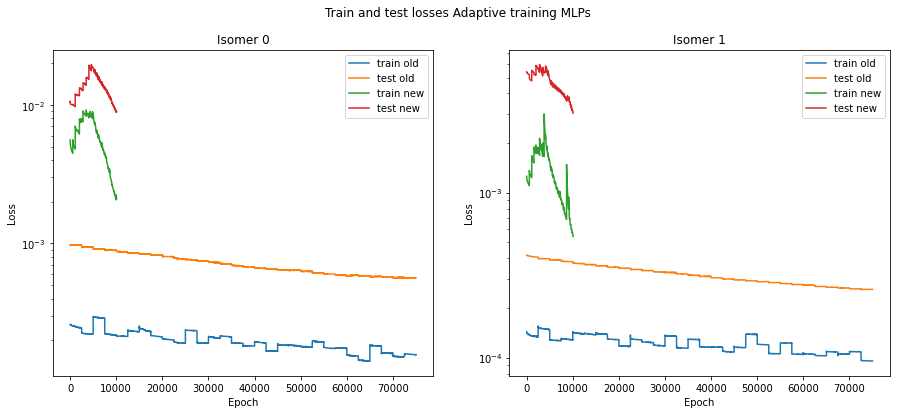

In [24]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

for sim in adaptives_old_new.keys():
    for key in adaptives_old_new[sim].keys():
        train_losses = []
        test_losses = []
        for training in adaptives_old_new[sim][key]['dict_mlps'][1:]:
            if sim == 'old':
                train_losses.append(training[0]['train_losses'])
                test_losses.append(training[0]['test_losses'])
            if sim == 'new':
                train_losses.append(training[0]['avg_train_losses'])
                test_losses.append(training[0]['avg_test_losses'])
        train_losses_flat = [loss for sublist in train_losses for loss in sublist]
        test_losses_flat = [loss for sublist in test_losses for loss in sublist]
        
        axs[key].plot(train_losses_flat, label='train {:s}'.format(sim))
        axs[key].plot(test_losses_flat, label='test {:s}'.format(sim))

        axs[key].set_title('Isomer {:d}'.format(key))
        axs[key].set_xlabel('Epoch')
        axs[key].set_ylabel('Loss')
        axs[key].legend()

        axs[key].set_yscale('log')

fig.suptitle('Train and test losses Adaptive training MLPs')

In [25]:
rhat_df = []
method = 'adaptive'
for simulation in simulation_types[method]:
    for isomer_label in [0, 1]:

        us = torch.cat(adaptives[simulation][isomer_label]['us']).reshape(1000, 50, 1)
        cvs = cvss[simulation][isomer_label]
        
        time_slices = adaptives[simulation][isomer_label]['time_mcmc']
        time_flatten = [t for time_slice in time_slices for t in time_slice]
        time_min = min(time_flatten)
        time_mcmc = np.array([t - time_min for t in time_flatten])/3600

        rhat_info = torch.cat((cvs, us), dim=2).detach().numpy()[500:].transpose(1, 0, 2)

        rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])
        time_ = time_mcmc[rhat[1]]
        time_min = min(time_)
        time_mcmc = np.array([t - time_min for t in time_])

        df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
        df['Time (h)'] = time_mcmc
        df['MCMC step'] = rhat[1]
        df['Method'] = simulation
        df['Isomer'] = isomer_label

        rhat_df.append(df)

rhat_df = pd.concat(rhat_df)

In [26]:
import seaborn as sns

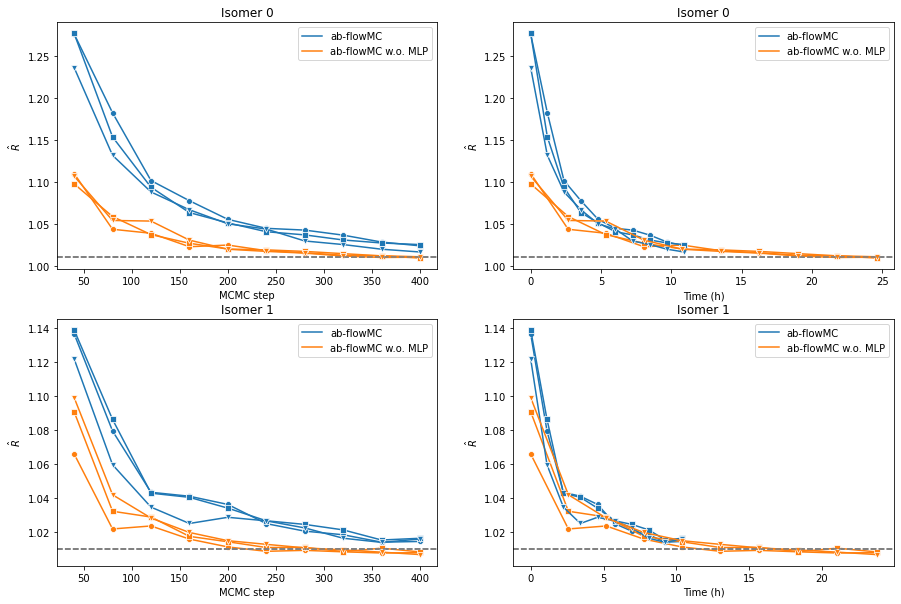

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
markers = dict(zip(['C', 'R', 'U'], ['o', 's', 'v']))
for isomer in [0, 1]:
    for j, x_axis in enumerate(['MCMC step', 'Time (h)']): 
        for y_axis in ['C', 'R', 'U']:    
            sns.lineplot(data=rhat_df[rhat_df['Isomer'] == isomer], 
                x=x_axis, 
                y=y_axis, 
                hue='Method',
                marker=markers[y_axis], 
                ax=axs[isomer, j],
                )

            axs[isomer, j].axhline(y=1.01, color='gray', linestyle='--')

            axs[isomer, j].set_title('Isomer {:d}'.format(isomer))
            axs[isomer, j].set_xlabel(x_axis)
            axs[isomer, j].set_ylabel(r'$\hat{R}$')


            handles, labels = axs[isomer, j].get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            axs[isomer, j].legend(by_label.values(), by_label.keys())

In [76]:
adaptives_old_new['old'][0]['args'].keys()

dict_keys(['threads', 'process_id', 'random_seed', 'folder_path', 'dataset', 'N', 'isomer_label', 'flow_n_iter', 'flow_learning_rate', 'flow_batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'flow_use_scheduler', 'flow_step_scheduler', 'mlp_n_iter', 'mlp_learning_rate', 'mlp_batch_size', 'mlp_use_scheduler', 'mlp_step_scheduler', 'temperature', 'n_runs', 'n_chains', 'n_steps', 'energy_type', 'frac_computed', 'train_mlps', 'load_models', 'flow_type', 'update_weights', 'scheduler_weights', 'alpha', 'mlps_id', 'flows_id', 'date_start', 'date_end', 'algorithm', 'time_init'])

In [80]:
columns = ['Number of iterations', 'Batch size', 'Learning rate']
rows = ['Previous results', 'New results']

df = pd.DataFrame(columns=columns, index=rows)
df['Number of iterations'] = [
    adaptives_old_new['old'][0]['args']['mlp_n_iter'],
    adaptives_old_new['new'][0]['args']['mlp_n_iter']
]
df['Batch size'] = [
    adaptives_old_new['old'][0]['args']['mlp_batch_size'],
    adaptives_old_new['new'][0]['args']['mlp_batch_size']
]

df['Learning rate'] = [
    adaptives_old_new['old'][0]['args']['mlp_learning_rate'],
    adaptives_old_new['new'][0]['args']['mlp_learning_rate']
]

In [81]:
df

,Number of iterations,Batch size,Learning rate
Previous results,2500,500,0.00001
New results,2500,500,0.00001
